<a href="https://colab.research.google.com/github/DioctonJM/DSP/blob/main/LAB_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

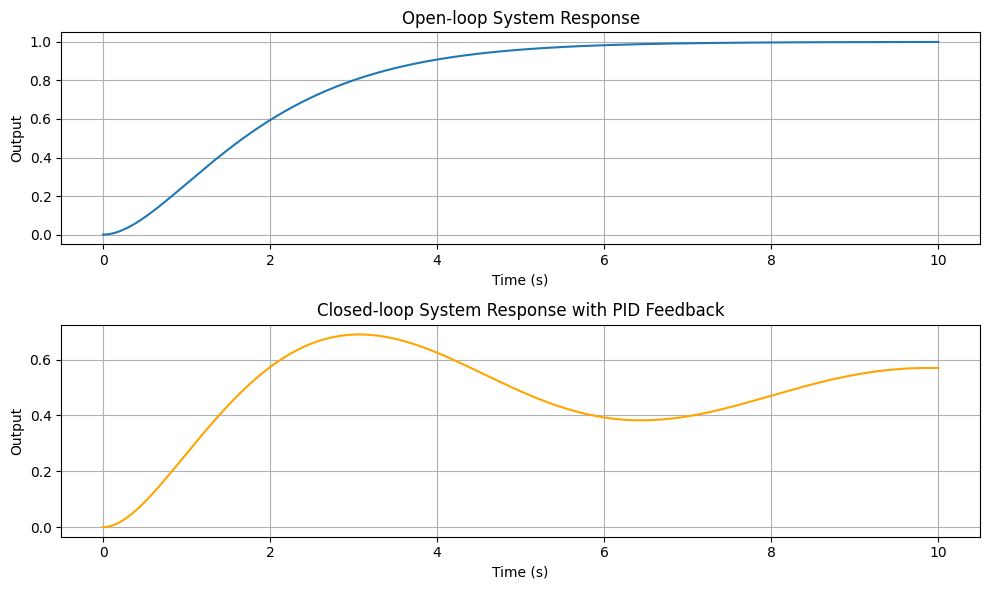

Steady-state error (Open-loop): 0.0004993992273878423
Steady-state error (Closed-loop): 0.4299018675034538


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Define a simple transfer function for the system (e.g., a DC motor)
# Transfer function: G(s) = 1 / (s^2 + 2s + 1) (for demonstration)

# Open-loop transfer function (without feedback)
num = [1]  # Numerator of the transfer function
den = [1, 2, 1]  # Denominator of the transfer function

# Define the PID controller transfer function
# PID controller: C(s) = Kp + Ki/s + Kd*s
Kp = 1  # Proportional gain
Ki = 1  # Integral gain
Kd = 1  # Derivative gain

# Define the closed-loop system with feedback
# Closed-loop transfer function H(s) = C(s) * G(s) / (1 + C(s) * G(s))
C = [Kd, Kp, Ki]  # PID controller transfer function coefficients

# Create the system (plant)
system = signal.TransferFunction(num, den)

# Closed-loop transfer function: Feedback system
closed_loop_num = np.polymul([Kd, Kp, Ki], num)  # Multiply the PID controller with system
closed_loop_den = np.polyadd(np.polymul([Kd, Kp, Ki], den), num)  # Add feedback

# Simulate the open-loop response
t = np.linspace(0, 10, 1000)  # Time array
t, y_open_loop = signal.step(system, T=t)  # Step response of open-loop system

# Simulate the closed-loop response
closed_loop_system = signal.TransferFunction(closed_loop_num, closed_loop_den)
t, y_closed_loop = signal.step(closed_loop_system, T=t)  # Step response of closed-loop system

# Plot the responses
plt.figure(figsize=(10, 6))

# Plot Open-loop response
plt.subplot(2, 1, 1)
plt.plot(t, y_open_loop, label="Open-loop Response")
plt.title('Open-loop System Response')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.grid(True)

# Plot Closed-loop response
plt.subplot(2, 1, 2)
plt.plot(t, y_closed_loop, label="Closed-loop Response", color='orange')
plt.title('Closed-loop System Response with PID Feedback')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.grid(True)

plt.tight_layout()
plt.show()

# Compute steady-state error (for step input)
steady_state_error_open_loop = np.abs(1 - y_open_loop[-1])
steady_state_error_closed_loop = np.abs(1 - y_closed_loop[-1])

print(f"Steady-state error (Open-loop): {steady_state_error_open_loop}")
print(f"Steady-state error (Closed-loop): {steady_state_error_closed_loop}")